In [1]:
import io
from collections import defaultdict
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import plotly.graph_objects as go
import plotly.io as pio
import yaml
from scipy.stats import genpareto, lognorm

from pandemic_model.stats.mevd import MEVD
from pandemic_model.stats.pareto import TruncatedGPD
from pandemic_model.utils import set_standard_plot_theme


In [2]:
set_standard_plot_theme()

In [3]:
THRESH = 0.01 # Lower bound for exceedance functions
YR_MIN = 1900 # Temporal lower bound for inclusion
YR_MAX = 2024

In [4]:
all_epidemics_ds = pd.read_excel("../../data/raw/epidemics_marani_240816.xlsx")
all_epidemics_ds = all_epidemics_ds.rename(columns={'severity_smu': 'severity'}) # Name change simplifies code later

Although the HIV pandemic has not ended, we set its duration to twice the time it took for it to achieve its peak in terms of annual deaths per 10,000. This peak was achieved in 2003. With an arrival year of 1980, we set the duration to 46 years. We set COVID-19 to terminate in 2024.

In [5]:
all_epidemics_ds.loc[all_epidemics_ds['disease'] == 'hiv/aids', 'duration'] = 46

In [6]:
all_epidemics_ds['transmission'].value_counts()

transmission
droplet                                     144
bite                                         85
feces                                        84
unknown                                      81
airborne/bite                                44
airborne/droplet                             35
droplet/feces                                21
airborne/droplet/fluid                       13
droplet/fluid                                12
bite/droplet/feces/fluid                      8
blood/fluid                                   3
fluid                                         2
airborne                                      2
feces; bite; feces                            1
feces; feces                                  1
feces; feces; feces                           1
feces (but also touching infected water)      1
bite/fluid                                    1
airborne/aspiration                           1
animalcontact/bite                            1
Name: count, dtype: int64

In [7]:
# Define airborne, unidentified and contagious epidemics
all_epidemics_ds['unidentified'] = (all_epidemics_ds['type'].str.contains("/")) | (all_epidemics_ds['type'] == 'unknown')
all_epidemics_ds['airborne'] = all_epidemics_ds['transmission'].str.contains('airborne|droplet')
all_epidemics_ds['contagious'] = ~all_epidemics_ds['transmission'].isin(['bite', 'animalcontact/bite'])
all_epidemics_ds['recurrent'] = all_epidemics_ds.groupby('disease')['year_start'].transform(lambda x: any(x < YR_MIN))

# Clean up for unidentified diseases
unid_idx = all_epidemics_ds['unidentified']
all_epidemics_ds.loc[unid_idx, 'transmission'] = 'unknown'
all_epidemics_ds.loc[unid_idx, 'recurrent'] = False
all_epidemics_ds.loc[all_epidemics_ds['disease'] == 'influenza', 'recurrent'] = False # Due to flu antigenic drift

Also define recurrent category up here to the best of your ability

In [8]:
with open("../../data/clean/inverted_covid_severity.yaml", 'rb') as f:
  inverted_covid_severity_dict = yaml.safe_load(f)
  inverted_covid_severity = inverted_covid_severity_dict['ex_ante_severity']

In [9]:
covid_19_duration = all_epidemics_ds.loc[all_epidemics_ds['disease'] == 'covid-19', 'duration'].iloc[0]
response_threshold = (inverted_covid_severity / covid_19_duration) / 2

In [10]:
all_epidemics_ds['intensity'] = all_epidemics_ds['severity'] / all_epidemics_ds['duration']

In [11]:
marani_params = {
  'shape': 1.40,
	'loc': 0.01,
  'scale':0.0113
}

In [12]:
all_modern_ds = all_epidemics_ds[all_epidemics_ds['year_start'] >= YR_MIN].copy()

In [13]:
def get_inclusion_path(row, thresh=THRESH):
    """
    Returns a list of node labels from column 0 through 5, 
    stopping at the first 'fail' (exclusion).
    
    0: "Epidemics since 1900"
    1: "Below detectability threshold" or "Above detectability threshold"
    2: "Non-viral" or "Viral"
    3: "Unidentified" or "Identified"
    4: "Not contagious" or "Contagious"
    5: "Not novel" or "Novel"
    """
    path = []
    
    # Column 0
    path.append("Epidemics since 1900")
    
    # Column 1
    if row['intensity'] < thresh:
        path.append("Below detectability threshold")
        return path
    else:
        path.append("Above detectability threshold")
    
    # Column 2
    if 'vira' not in row['type']:
        path.append("Non-viral")
        return path
    else:
        path.append("Viral")
    
    # Column 3
    if not row['contagious']:
        path.append("Not contagious")
        return path
    else:
        path.append("Contagious")
        
    # Column 4
    if row['unidentified']:
        path.append("Unidentified")
        return path
    else:
        path.append("Identified")
    
    # Column 5
    if row['recurrent']:
        path.append("Recurrent")
    else:
        path.append("Novel")
    
    return path

In [14]:
def plot_tidy_binary_sankey(df, title="Epidemic Exclusion Flow"):
    """
    Creates a tidy Sankey with exactly 6 columns:
      0: ["All data"]
      1: ["Below detectability threshold", "Above detectability threshold"]
      2: ["Non-viral", "Viral"]
      3: ["Unidentified", "Identified"]
      4: ["Not contagious", "Contagious"]
      5: ["Recurrent", "Novel"]
    
    We truncate each row's path at the first failure, 
    so no self-loops are produced.
    
    Flows to excluded nodes are colored gray; 
    pass flows are colored by the source node's color.
    """
    # A) Define columns
    columns = [
        ["Epidemics since 1900"], 
        ["Below detectability threshold", "Above detectability threshold"],
        ["Non-viral", "Viral"],
        ["Not contagious", "Contagious"],
        ["Unidentified", "Identified"],
        ["Recurrent", "Novel"]
    ]
    
    node_list = []
    for col in columns:
        node_list.extend(col)
    
    node_index = {lbl: i for i, lbl in enumerate(node_list)}
    
    # "excluded" nodes for coloring flows gray
    excluded_nodes = {
        "Below detectability threshold",
        "Non-viral",
        "Not contagious",
        "Unidentified",
        "Recurrent"
    }
    
    # B) Gather flows and counts
    flows = defaultdict(int)
    node_counts = defaultdict(int)
    
    for _, row in df.iterrows():
        path = get_inclusion_path(row)
        # Count nodes
        for node in path:
            node_counts[node] += 1
        # Add edges from path[i] -> path[i+1]
        for i in range(len(path) - 1):
            src, tgt = path[i], path[i+1]
            flows[(src, tgt)] += 1
    
    # Add counts to labels
    node_list_with_counts = [
        f"{lbl}<br>[n={node_counts[lbl]}]" for lbl in node_list
    ]
    
    # Build Sankey lists
    source_list = []
    target_list = []
    value_list = []
    for (s_lbl, t_lbl), count in flows.items():
        source_list.append(node_index[s_lbl])
        target_list.append(node_index[t_lbl])
        value_list.append(count)
    
    # C) Position each node in columns uniformly
    node_x = [0]*len(node_list)
    node_y = [0]*len(node_list)
    
    for col_i, col_nodes in enumerate(columns):
        if len(col_nodes) == 1:
            # e.g. column 0 has just "All data"
            n_lbl = col_nodes[0]
            idx = node_index[n_lbl]
            node_x[idx] = float(col_i)
            node_y[idx] = 0.5
        else:
            # 2 outcomes
            upper_lbl, lower_lbl = col_nodes[0], col_nodes[1]
            upper_idx = node_index[upper_lbl]
            lower_idx = node_index[lower_lbl]

            node_x[lower_idx] = float(col_i)
            node_y[lower_idx] = 0.5 

            node_x[upper_idx] = float(col_i)
            node_y[upper_idx] = 0.52
    
    # Normalize to [0,1]
    min_x, max_x = min(node_x), max(node_x)
    min_y, max_y = min(node_y), max(node_y)
    dx = max_x - min_x if max_x != min_x else 1
    dy = max_y - min_y if max_y != min_y else 1
    pad = 0.05
    node_x_norm = [pad + (x - min_x)/dx*(1-2*pad) for x in node_x]
    node_y_norm = [pad + (y - min_y)/dy*(1-2*pad) for y in node_y]
    
    # D) Colors
    color_map = {
        "Epidemics since 1900": "rgba(76,114,176,0.8)",
        "Above detectability threshold": "rgba(221,132,82,0.8)",
        "Below detectability threshold": "rgba(221,132,82,0.4)",
        "Viral": "rgba(85,168,104,0.8)",
        "Non-viral": "rgba(85,168,104,0.4)",
        "Contagious": "rgba(129,114,179,0.8)",
        "Not contagious": "rgba(129,114,179,0.4)",
        "Identified": "rgba(196,78,82,0.8)",
        "Unidentified": "rgba(196,78,82,0.4)",
        "Novel": "rgba(147,120,96,0.8)",
        "Recurrent": "rgba(147,120,96,0.4)",
    }
    
    node_colors = [
        "rgba(150,150,150,0.8)" if lbl in excluded_nodes else color_map.get(lbl, "rgba(180,180,180,0.8)")
        for lbl in node_list
    ]
    
    # Link color: if target is an "excluded" node, grey; else color by source
    link_colors = []
    for s_i, t_i in zip(source_list, target_list):
        s_lbl = node_list[s_i]
        t_lbl = node_list[t_i]
        if t_lbl in excluded_nodes:
            link_colors.append("rgba(150,150,150,0.7)")
        else:
            link_colors.append(color_map.get(s_lbl, "rgba(180,180,180,0.8)"))
    
    # E) Build Plotly Sankey
    fig = go.Figure(data=[
        go.Sankey(
            arrangement="fixed",
            node=dict(
                pad=15,
                thickness=15,
                line=dict(color="black", width=0.3),
                x=node_x_norm,
                y=node_y_norm,
                color=node_colors,
                hovertemplate="%{label}",
            ),
            link=dict(
                source=source_list,
                target=target_list,
                value=value_list,
                color=link_colors
            )
        )
    ])
    
    fig.update_layout(
        font=dict(family="Arial", size=12, color='black'),
        title_font_size=12,
        paper_bgcolor='white',
        plot_bgcolor='white',
        margin=dict(l=40, r=40, t=160, b=100),
        width=1200,
        height=600
    )
    
    for i, lbl in enumerate(node_list_with_counts):
        if "Epidemics since 1900" in lbl:
            offset = -1.3  # bigger offset for the first column
        elif "Below detectability threshold" in lbl:
            offset = -0.3
        else:
            # Decrease offset as i increases (make it smaller in absolute terms)
            offset = -0.15 + ((i-1) * 0.012)  # offset gets closer to zero as i increases
            
        # Create index that pairs nodes with same integer division by 2
        if i == 0:
            index = 0
        elif i % 2 == 0:
            index = i - 1
        else:
            index = i + 1
            
        fig.add_annotation(
						x=node_x_norm[index],
						y=node_y_norm[index] - offset,  # shift label above the node
						text=lbl,
						showarrow=False,
						xanchor="center",  # center the text horizontally over the node
						yanchor="bottom",  # the annotation's bottom edge is at (y-offset)
						font=dict(size=14.5, color="black")
				)
    
    img_bytes = pio.to_image(fig, format="png", scale=4)
    mpl_fig, ax = plt.subplots(figsize=(10, 5), dpi=600)
    ax.imshow(plt.imread(io.BytesIO(img_bytes)))
    ax.axis("off")
    mpl_fig.tight_layout()

    return mpl_fig, ax

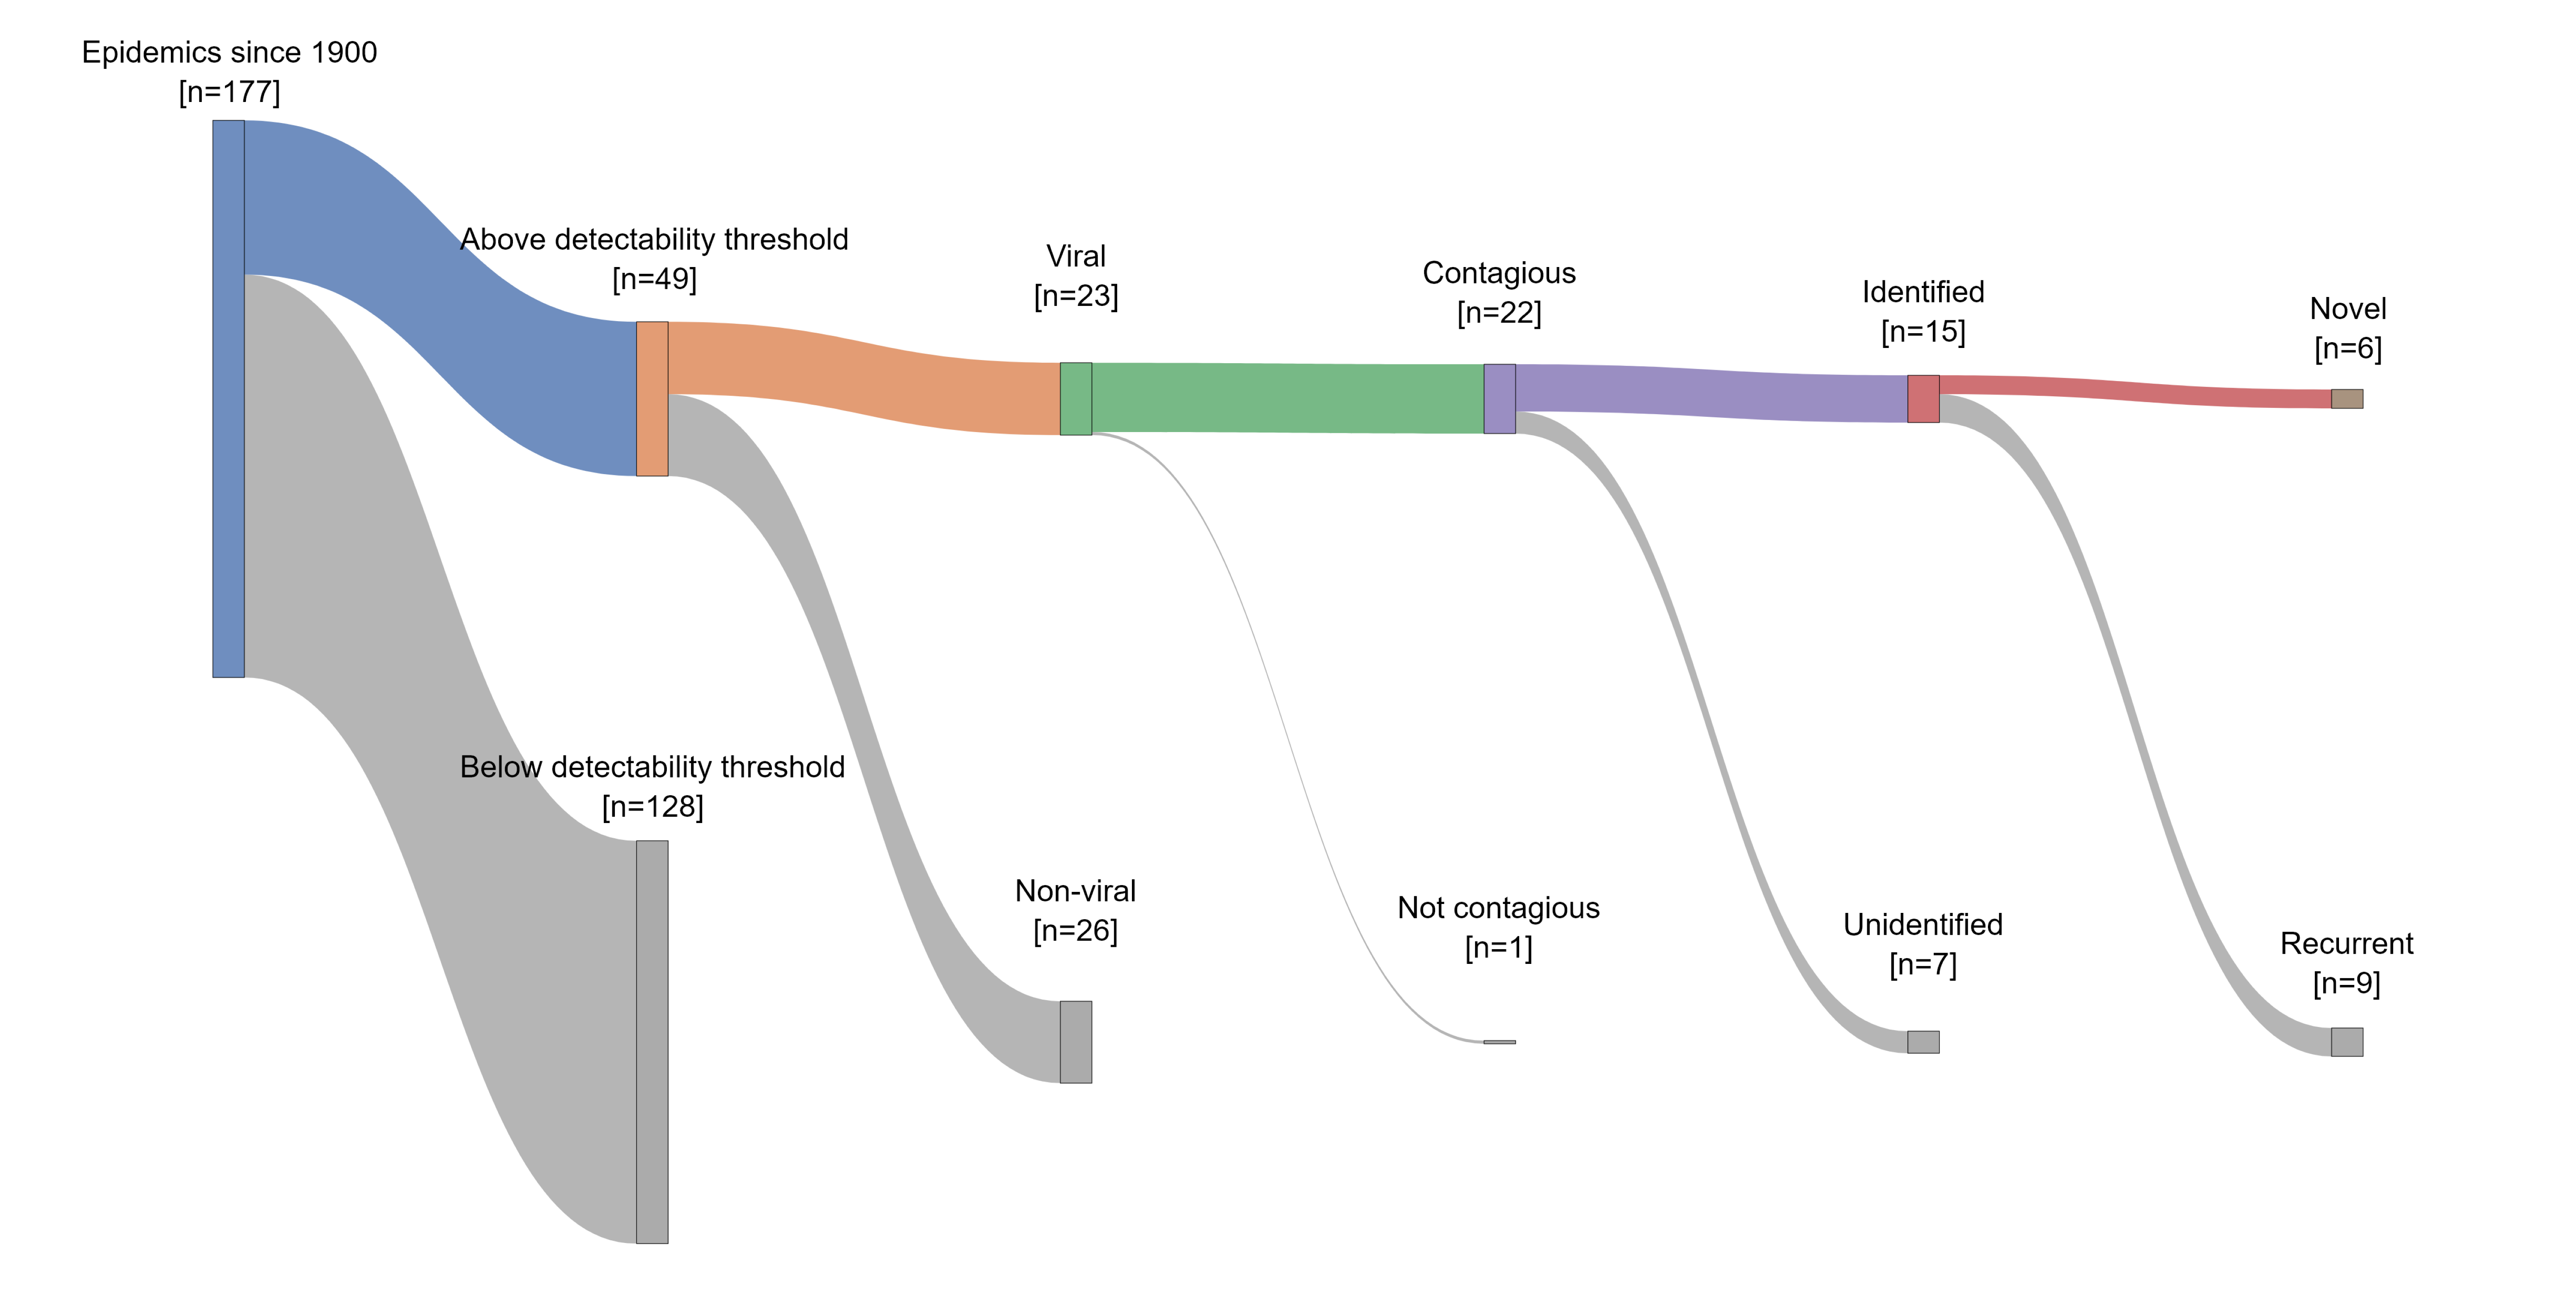

In [15]:
fig, ax = plot_tidy_binary_sankey(all_modern_ds)

In [16]:
fig.savefig("../../output/dataset_filter_sankey.png", dpi=400)

#### Construct datasets for exceedance function fitting

In [17]:
all_modern_ds['final_inclusion_node'] = all_modern_ds.apply(lambda x: get_inclusion_path(x)[-1], axis=1)
final_allrisk_ds = all_modern_ds[all_modern_ds['final_inclusion_node'] == 'Novel']
final_airborne_ds = final_allrisk_ds[final_allrisk_ds['airborne']]

In [18]:
fit_dfs = {
	'Novel since 1900': final_allrisk_ds,
	'Novel airborne since 1900': final_airborne_ds
}
upper_bound = final_allrisk_ds['intensity'].max()
fixed_params = {'loc': THRESH, 'upper_bound': upper_bound}

Experiment with applying [Cirillo and Taleb](https://www.nature.com/articles/s41567-020-0921-x) inverse log transformation.

In [19]:
arrival_distr_allrisk = TruncatedGPD.fit(final_allrisk_ds['intensity'], fixed=fixed_params)
arrival_distr_allrisk_ext = TruncatedGPD.fit(final_allrisk_ds['intensity'], fixed={'loc': THRESH, 'upper_bound': 1e4})
arrival_distr_airborne = TruncatedGPD.fit(final_airborne_ds['intensity'], fixed=fixed_params)
arrival_distr_marani = genpareto(marani_params['shape'], loc=marani_params['loc'], scale=marani_params['scale'])

In [20]:
def get_annual_arrival_counts(df: pd.DataFrame, start_year, end_year):
		years = np.arange(start_year, end_year + 1)
		arrival_counts = pd.Series(0, index=years)

		eval_df = df[df['year_start'].between(start_year, end_year)]
		df_counts = eval_df.groupby('year_start').size()
		arrival_counts.loc[df_counts.index] = df_counts

		return arrival_counts

arrival_window = [YR_MIN, YR_MAX]

#### Exceedance curves

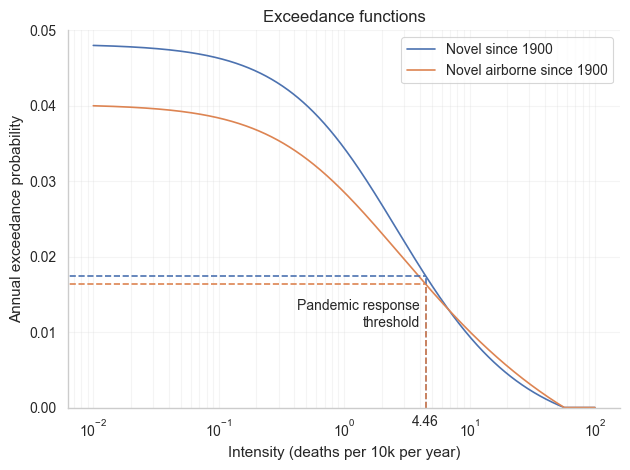

In [62]:
fig, ax = plt.subplots()
distributions = {
  # 'Marani et al.': arrival_distr_marani,
  'Novel since 1900': arrival_distr_allrisk, 
  'Novel airborne since 1900': arrival_distr_airborne
}
x = np.logspace(np.log10(THRESH), np.ceil(np.log10(upper_bound)), 1000)

arrival_counts_dict = {}
for name, distr in distributions.items():
		arrival_counts = get_annual_arrival_counts(fit_dfs[name], *arrival_window)
		mevd = MEVD(arrival_counts, distr)
		
		y = mevd.sf(x)
		ax.semilogx(x, y, label=f'{name}', linestyle='-')

		arrival_counts_dict[name] = arrival_counts

ax.set_ylim([0, 0.05])
ax.legend()
ax.set_xlabel(f'Intensity (deaths per 10k per year)')
ax.set_ylabel('Annual exceedance probability')
ax.set_title("Exceedance functions")
ax.grid(True, which='both', ls='-', alpha=0.2)
ax.spines[['top', 'right']].set_visible(False)
fig.tight_layout()

# Save base plot
outdir = Path("../../output/severity_distributions")
outdir.mkdir(parents=True, exist_ok=True)
plt.savefig(outdir / "pilot_distributions_no_threshold.png", dpi=500, bbox_inches='tight')

# Get exceedance probabilities at threshold
threshold_probs = {}
for name, distr in distributions.items():
    arrival_counts = arrival_counts_dict[name]
    mevd = MEVD(arrival_counts, distr)
    threshold_probs[name] = mevd.sf(response_threshold)

# Plot horizontal and vertical lines to exceedance probabilities
colors = plt.gca().lines[-2:] # Get colors from existing lines
for (name, prob), line in zip(threshold_probs.items(), colors):
    ax.hlines(y=prob, xmin=0, xmax=response_threshold,
              colors=line.get_color(), linestyles='--')

    ax.vlines(x=response_threshold, ymin=0, ymax=prob,
              colors=line.get_color(), linestyles='--')
    
# Add text label for threshold
text_x = response_threshold*0.9
text_y = min(tuple(threshold_probs.values())) / 2
ax.text(text_x, text_y, f'Pandemic response\nthreshold\n', va='bottom', ha='right')

# Add text label for threshold value on x axis
text_x = response_threshold
text_y = -0.001
ax.text(text_x, text_y, f'{response_threshold:.2f}', va='top', ha='center')

plt.savefig(outdir / "pilot_distributions_with_threshold.png", dpi=500, bbox_inches='tight')

In [22]:
# Calculate recurrence times at threshold for each distribution
recurrence_times = {}
for name, distr in distributions.items():
    arrival_counts = arrival_counts_dict[name]
    mevd = MEVD(arrival_counts, distr)
    prob = mevd.sf(response_threshold)
    recurrence_time = 1/prob if prob > 0 else float('inf')
    recurrence_times[name] = float(recurrence_time[0])

# Print recurrence times
print("\nRecurrence times at pandemic response threshold:")
for name, rt in recurrence_times.items():
    print(f"{name}: {rt:.1f} years")



Recurrence times at pandemic response threshold:
Novel since 1900: 57.2 years
Novel airborne since 1900: 61.1 years


#### Write configs so they can be ported to Matlab

In [23]:
# Get original counts and create versions with half/double number of ones
allrisk_arrival_counts = arrival_counts_dict['Novel since 1900']
allrisk_arrival_counts_half = allrisk_arrival_counts.copy()
allrisk_arrival_counts_double = allrisk_arrival_counts.copy()

# Get indices of ones and zeros
one_indices = allrisk_arrival_counts[allrisk_arrival_counts == 1].index
zero_indices = allrisk_arrival_counts[allrisk_arrival_counts == 0].index

# Set half the ones to zero
half_ones_to_zero = np.random.choice(one_indices, size=len(one_indices)//2, replace=False)
allrisk_arrival_counts_half.loc[half_ones_to_zero] = 0

# Set half the zeros to one
zeros_to_one = np.random.choice(zero_indices, size=len(one_indices), replace=False)
allrisk_arrival_counts_double.loc[zeros_to_one] = 1

# Verify the counts are correct
original_ones = allrisk_arrival_counts.sum()
half_ones = allrisk_arrival_counts_half.sum()
double_ones = allrisk_arrival_counts_double.sum()
assert half_ones == original_ones // 2, f"Half count {half_ones} != {original_ones // 2}"
assert double_ones == original_ones * 2, f"Double count {double_ones} != {original_ones * 2}"

In [24]:
original_ones, half_ones, double_ones

(np.int64(6), np.int64(3), np.int64(12))

In [25]:
allrisk_arrival_config = { # Baseline allrisk
		'metric': 'intensity',
		'lower_bound': float(arrival_distr_allrisk.loc),
		'upper_bound': float(arrival_distr_allrisk.upper),
		'base_dist_family': 'GeneralizedPareto',
		'truncation': 'smooth',
		'base_dist_params': { # Will have to revise this if we use other distributions
				'k': float(arrival_distr_allrisk.xi),
				'theta': float(arrival_distr_allrisk.loc),
				'sigma': float(arrival_distr_allrisk.scale)
		},
		'arrival_counts': arrival_counts_dict['Novel since 1900'].tolist()
}

allrisk_arrival_ext_config = { # Extinction upper bound
  	'metric': 'intensity',
  	'lower_bound': float(arrival_distr_allrisk_ext.loc),
		'upper_bound': float(arrival_distr_allrisk_ext.upper),
		'base_dist_family': 'GeneralizedPareto',
		'truncation': 'smooth',
		'base_dist_params': { # Will have to revise this if we use other distributions
				'k': float(arrival_distr_allrisk_ext.xi),
				'theta': float(arrival_distr_allrisk_ext.loc),
				'sigma': float(arrival_distr_allrisk_ext.scale)
		},
		'arrival_counts': arrival_counts_dict['Novel since 1900'].tolist()
}

allrisk_arrival_half_arrival_config = { # Half the arrival rate
  	'metric': 'intensity',
  	'lower_bound': float(arrival_distr_allrisk.loc),
		'upper_bound': float(arrival_distr_allrisk.upper),
		'base_dist_family': 'GeneralizedPareto',
		'truncation': 'smooth',
		'base_dist_params': { # Will have to revise this if we use other distributions
				'k': float(arrival_distr_allrisk.xi),
				'theta': float(arrival_distr_allrisk.loc),
				'sigma': float(arrival_distr_allrisk.scale)
		},
		'arrival_counts': allrisk_arrival_counts_half.tolist()
}

allrisk_arrival_double_arrival_config = { # Double the arrival rate
  	'metric': 'intensity',
  	'lower_bound': float(arrival_distr_allrisk.loc),
		'upper_bound': float(arrival_distr_allrisk.upper),
		'base_dist_family': 'GeneralizedPareto',
		'truncation': 'smooth',
		'base_dist_params': { # Will have to revise this if we use other distributions
				'k': float(arrival_distr_allrisk.xi),
				'theta': float(arrival_distr_allrisk.loc),
				'sigma': float(arrival_distr_allrisk.scale)
		},
		'arrival_counts': allrisk_arrival_counts_double.tolist()
}

airborne_arrival_config = {
		'metric': 'intensity',
		'lower_bound': float(arrival_distr_airborne.loc),
		'upper_bound': float(arrival_distr_airborne.upper),
		'base_dist_family': 'GeneralizedPareto',
		'truncation': 'smooth',
		'base_dist_params': { # Will have to revise this if we use other distributions
				'k': float(arrival_distr_airborne.xi),
				'theta': float(arrival_distr_airborne.loc),
				'sigma': float(arrival_distr_airborne.scale)
		},
		'arrival_counts': arrival_counts_dict['Novel airborne since 1900'].tolist()
}

In [26]:
outdir = Path("../../") / "output" / "severity_distributions"

with open(outdir / "allrisk_base.yaml", "w") as f:
		yaml.dump(allrisk_arrival_config, f)
	
with open(outdir / "airborne_base.yaml", 'w') as f:
		yaml.dump(airborne_arrival_config, f)

with open(outdir / "allrisk_base_ext.yaml", "w") as f:
    yaml.dump(allrisk_arrival_ext_config, f)

with open(outdir / "allrisk_base_double_arrival.yaml", "w") as f:
    yaml.dump(allrisk_arrival_double_arrival_config, f)

with open(outdir / "allrisk_base_half_arrival.yaml", "w") as f:
    yaml.dump(allrisk_arrival_half_arrival_config, f)

#### Duration distributions

In [27]:
# Fit duration distributions
duration_distr_dict = {}

for name, df in fit_dfs.items():
	params = lognorm.fit(df['duration'], floc=0)
	duration_distr_dict[name] = {
		'shape': params[0],
		'loc': params[1],
		'scale': params[2]
	}

In [28]:
MAX_DURATION = 10 # Years

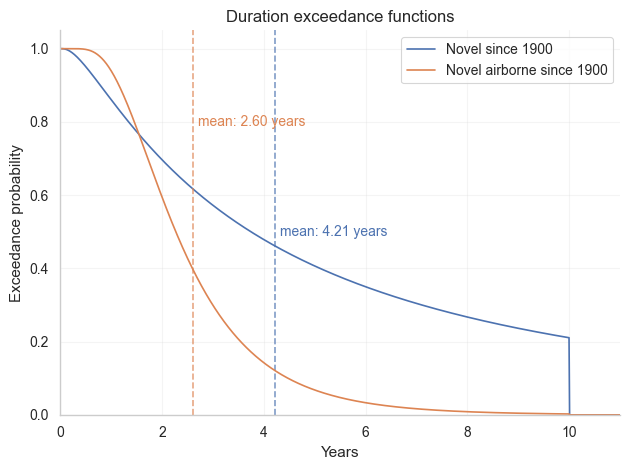

In [80]:
fig, ax = plt.subplots()

if not np.isfinite(MAX_DURATION):
		max_x = max([df['duration'].max() for df in fit_dfs.values()]) + 2
else:
		max_x = MAX_DURATION + 1

x = np.linspace(0, max_x, 1000)

# Fit and plot
means = {}
duration_configs = {}
for name, params in duration_distr_dict.items():
		s, loc, scale = tuple(params.values())
		exceedance = lognorm.sf(x, s, loc=loc, scale=scale)
		exceedance[x > MAX_DURATION] = 0
		ax.plot(x, exceedance, label=f'{name}')
		
		# Mean with truncation - mass below * conditional mean + mass above * max duration
		# Calculate truncated mean: E[min(X, max_duration)]
		cdf_at_max = lognorm.cdf(MAX_DURATION, s, loc=loc, scale=scale)
		mean = (
				lognorm.expect(lambda x: x, args=(s,), loc=loc, scale=scale, lb=0, ub=MAX_DURATION) * cdf_at_max +
				MAX_DURATION * (1 - cdf_at_max)
		)
		means[name] = mean
		# Plot vertical line at the mean
		ax.axvline(x=mean, linestyle='--', color=ax.lines[-1].get_color(), alpha=0.7)

		# Save duartion config
		duration_config = {
				'dist_family': "Lognormal",
				'max_duration': float(MAX_DURATION),
				'params': {
						'mu': float(np.log(scale)),
						'sigma': float(s)
				}
		}

		duration_configs[name] = duration_config


# Configure axes
legend_entries = []
for name in duration_distr_dict.keys():
		legend_entries.append(f'{name}')
		legend_entries.append(f'{name} mean ({means[name]:.2f} years)')

ax.legend(loc='upper right')
ax.set_xlabel('Years')
ax.set_ylabel('Exceedance probability')
ax.set_xlim(0, max_x)
ax.set_ylim(0, 1.05)
ax.set_title('Duration exceedance functions')
ax.spines[['top', 'right']].set_visible(False)
ax.grid(True, which='both', ls='-', alpha=0.2)

# Add labels to the plot
for i, entry in enumerate(legend_entries):
    if i % 2 == 0:  # Only process the base entries, not the mean entries
        mean_val = means[entry]
        # Get y value from exceedance curve at mean_val
        y_pos = 0.5 if entry == 'Novel since 1900' else 0.8
        ax.text(mean_val + 0.1, y_pos, f'mean: {mean_val:.2f} years',
                rotation=0,
                horizontalalignment='left', 
                verticalalignment='center',
                color=ax.lines[i].get_color())



plt.tight_layout()

# Save plot
outdir = Path("../../") / "output" / "duration_distributions"
outdir.mkdir(parents=True, exist_ok=True)
plt.savefig(outdir / "duration_exceedance.png", bbox_inches='tight', dpi=500)


In [30]:
# Save config               
outdir = Path("../../") / "output" / "duration_distributions"
allrisk_duration_config = duration_configs['Novel since 1900']
airborne_duration_config = duration_configs['Novel airborne since 1900']

In [31]:
## Save duration distributions
with open(outdir / "allrisk_base.yaml", 'w') as f:
		yaml.dump(allrisk_duration_config, f)

with open(outdir / "airborne_base.yaml", 'w') as f:
		yaml.dump(airborne_duration_config, f)

In [32]:
# Set random seed for reproducibility
np.random.seed(42)

# Calculate expected annual losses using inverse transform sampling
n_samples = 300000

# Create MEVD distributions
allrisk_mevd = MEVD(arrival_counts_dict['Novel since 1900'], arrival_distr_allrisk)
airborne_mevd = MEVD(arrival_counts_dict['Novel airborne since 1900'], arrival_distr_airborne)

# Sample intensities using MEVD
u_intensities = np.random.uniform(size=n_samples)
allrisk_intensities = allrisk_mevd.ppf(u_intensities)
airborne_intensities = airborne_mevd.ppf(u_intensities)

# Sample durations
allrisk_dist = lognorm(s=allrisk_duration_config['params']['sigma'],
                      scale=np.exp(allrisk_duration_config['params']['mu']))
airborne_dist = lognorm(s=airborne_duration_config['params']['sigma'],
                       scale=np.exp(airborne_duration_config['params']['mu']))

u_durations = np.random.uniform(size=n_samples)
allrisk_durations = np.round(allrisk_dist.ppf(u_durations))
airborne_durations = np.round(airborne_dist.ppf(u_durations))
allrisk_durations[allrisk_durations > allrisk_duration_config['max_duration']] = allrisk_duration_config['max_duration']
airborne_durations[airborne_durations > airborne_duration_config['max_duration']] = airborne_duration_config['max_duration']

# Set intensities below 4.45 to zero
allrisk_intensities_high = allrisk_intensities.copy()
airborne_intensities_high = airborne_intensities.copy()
allrisk_intensities_high[allrisk_intensities <= 4.45] = 0
airborne_intensities_high[airborne_intensities <= 4.45] = 0

# Calculate expected annual losses including zeros
allrisk_annual_losses = np.mean(allrisk_intensities_high * allrisk_durations * 7.91e5)
airborne_annual_losses = np.mean(airborne_intensities_high * airborne_durations * 7.91e5)

print(f"Expected annual losses (intensities > 4.45):")
print(f"All risk: {allrisk_annual_losses:.2f}")
print(f"Airborne: {airborne_annual_losses:.2f}")

Expected annual losses (intensities > 4.45):
All risk: 1033641.71
Airborne: 616050.82


In [60]:
# Create a publication-quality LaTeX table of diseases
final_ds = fit_dfs['Novel since 1900']
table_data = final_ds[['disease', 'transmission', 'intensity', 'duration', 'year_start', 'year_end']].copy()
table_data['disease'] = table_data['disease'].str.title()
table_data.loc[table_data['transmission'].str.contains('airborne'), 'transmission'] = 'droplet'
table_data.loc[table_data['disease'] == 'Hiv/Aids', 'disease'] = "HIV/AIDS"
table_data.loc[table_data['disease'] == 'Covid-19', 'disease'] = "COVID-19"

# Sort by start year ascending
table_data = table_data.sort_values('year_start', ascending=True)

# Create LaTeX table string
latex_table = "\\begin{table}[t!]\n\\centering\n"
latex_table += "\\caption{Final all risks dataset}\n"
latex_table += "\\small\n"
latex_table += "\\begin{tabularx}{\\textwidth}{l>{\\centering\\arraybackslash}Xccc>{\\centering\\arraybackslash}X}\n"  # Two centered X columns
latex_table += "\\toprule\n"
latex_table += "Disease & Transmission mode & Intensity (SU) & Start year & End year & Duration (years) \\\\\n"
latex_table += "\\midrule\n"

hiv_start_year = table_data.loc[table_data['disease'] == 'HIV/AIDS', 'year_start'].astype(int).iloc[0]
# Add rows
for _, row in table_data.iterrows():
    latex_table += f"{row['disease']} & "
    # The transmission column will now automatically wrap
    latex_table += f"{row['transmission'].replace('/', ' / ').title()} & "
    latex_table += f"{row['intensity']:.2f} & "
    latex_table += f"{int(row['year_start'])} & "
    latex_table += f"{int(row['year_end'])} & "
    latex_table += f"{int(row['duration'])} \\\\\n"

latex_table += "\\bottomrule\n"
latex_table += "\\end{tabularx}\n"  # Changed to end tabularx
latex_table += "\\label{tab:disease_events}\n"
latex_table += f"""\\caption*{{\\footnotesize{{Intensity is given in our standard units (SU), which are deaths per 10,000 individuals in the year of the disease's emergence.
The duration of HIV/AIDS is set by doubling the time to its peak mortality since its emergence in {hiv_start_year}.}}}}\n"""
latex_table += "\\end{table}"

# Print LaTeX table code
print(latex_table)

# Optionally save to file
outdir = Path("../../") / "output"
with open(outdir / "final_ds_table.tex", "w") as f:
    f.write(latex_table)

\begin{table}[t!]
\centering
\caption{Final all risks dataset}
\small
\begin{tabularx}{\textwidth}{l>{\centering\arraybackslash}Xccc>{\centering\arraybackslash}X}
\toprule
Disease & Transmission mode & Intensity (SU) & Start year & End year & Duration (years) \\
\midrule
Influenza & Droplet & 56.94 & 1918 & 1920 & 3 \\
Influenza & Droplet & 3.48 & 1957 & 1958 & 2 \\
Influenza & Droplet & 1.41 & 1968 & 1969 & 2 \\
HIV/AIDS & Fluid & 2.03 & 1981 & 2024 & 46 \\
Influenza & Droplet & 0.41 & 2009 & 2009 & 1 \\
COVID-19 & Droplet & 1.83 & 2019 & 2024 & 5 \\
\bottomrule
\end{tabularx}
\label{tab:disease_events}
\caption*{\footnotesize{Intensity is given in our standard units (SU), which are deaths per 10,000 individuals in the year of the disease's emergence.
The duration of HIV/AIDS is set by doubling the time to its peak mortality since its emergence in 1981.}}
\end{table}
